In [542]:

import pandas as pd
import datetime as datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

class trader():
    def __init__(self):
        self.in_buy = 0
        self.in_sell = 0
        self.buy_price = 0
        self.sell_price = 0
        self.stop_loss = 0
        self.take_profit = 0
        self.trades = []
        self.pnl = [0]
        self.dates = []
        self.buy_prices = []
        self.sell_prices = []
        self.fee = 0
        self.a = 25000
        self.account = [self.a]
        self.r = 0
        self.opening = 0
        self.notionals = []
        self.unit_trades = []
        self.n_list = []
        self.slippage = 0

    def reset(self):
        self.in_buy = 0
        self.in_sell = 0
        self.buy_price = 0
        self.sell_price = 0
        self.stop_loss = 0
        self.take_profit = 0
        self.slippage = 0

    def close_pos(self, date):
        self.n = int(min(self.a*0.01/self.r, 4*self.a/self.opening))
        self.n_list.append(self.n)
        self.notionals.append(self.n*self.opening)
        self.trades.append((self.sell_price - self.buy_price)*self.n - (2*self.n*self.fee) - (self.slippage*self.n))
        self.unit_trades.append(self.trades[-1]/self.n)
        self.a = self.a + self.trades[-1]
        self.account.append(self.a)
        self.pnl.append(self.pnl[-1] + self.trades[-1])
        self.dates.append(date)
        self.buy_prices.append(self.buy_price)
        self.sell_prices.append(self.sell_price)


In [543]:
qqq_df = pd.read_csv('Data/QQQ_5min_10years_UTC.csv')

qqq_df['date'] = pd.to_datetime(qqq_df['date'], utc=True).dt.tz_convert('America/New_York').dt.tz_localize(None)

qqq_df['day'] = qqq_df['date'].dt.date
qqq_df['time'] = qqq_df['date'].dt.time

qqq_df = qqq_df[qqq_df['day'] >= datetime.date(2016,1,1)]
qqq_df = qqq_df[qqq_df['day'] <= datetime.date(2023,2,17)]

qqq_df = qqq_df[qqq_df['time'] >= datetime.time(9,25,0)]
qqq_df = qqq_df[qqq_df['time'] <= datetime.time(15,55,0)]

qqq_df_copy = qqq_df.copy()

In [544]:
nq_df = pd.read_csv('Data/nq-10y-1min.csv')

nq_df['date'] = pd.to_datetime(
    nq_df['Date'].astype(str) + ' ' + nq_df['Time'].astype(str),
    format='%d/%m/%Y %H:%M:%S'
)

nq_df['date'] = (
    nq_df['date']
        .dt.tz_localize('America/Chicago')
        .dt.tz_convert('America/New_York')
        .dt.tz_localize(None)
)

nq_df = (
    nq_df.sort_values('date')
         .set_index('date')
         .resample('5min')
         .agg({
             'Open': 'first',
             'High': 'max',
             'Low': 'min',
             'Close': 'last',
             'TotalVolume': 'sum'
         })
         .dropna(subset=['Open', 'High', 'Low', 'Close'])
         .reset_index()
)

nq_df.rename(columns={'Open':'open','High':'high','Low':'low','Close':'close','TotalVolume':'totalvolume'}, inplace=True)

nq_df['day'] = nq_df['date'].dt.date
nq_df['time'] = nq_df['date'].dt.time

nq_df = nq_df[nq_df['day'] >= datetime.date(2016, 1, 1)]
nq_df = nq_df[nq_df['day'] <= datetime.date(2023, 2, 17)]

nq_df = nq_df[nq_df['time'] >= datetime.time(9, 25, 0)]
nq_df = nq_df[nq_df['time'] <= datetime.time(15, 55, 0)]

nq_df_copy = nq_df.copy()

In [545]:
aligned_idx = qqq_df['date']

nq_df = (
    nq_df.set_index('date')
         .reindex(aligned_idx)   # indice allineato a QQQ
         #.ffill()                # riempi i valori mancanti con l'ultimo valore disponibile
)

nq_df.index.name = 'date'
nq_df = nq_df.reset_index()      # riporti la colonna `date`
nq_df['day'] = nq_df['date'].dt.date
nq_df['time'] = nq_df['date'].dt.time


In [546]:
# quante barre hanno valori mancanti
missing_mask = nq_df[['open', 'high', 'low', 'close', 'totalvolume']].isna().any(axis=1)
missing_count = missing_mask.sum()
print(f"Barre con NaN: {missing_count}")

# date interessate (dopo il reindex coincidono con i giorni QQQ)
missing_days = nq_df.loc[missing_mask, 'day'].unique()
print(missing_days)


Barre con NaN: 506
[datetime.date(2016, 11, 25) datetime.date(2017, 7, 3)
 datetime.date(2017, 11, 24) datetime.date(2018, 7, 3)
 datetime.date(2018, 11, 23) datetime.date(2018, 12, 24)
 datetime.date(2019, 7, 3) datetime.date(2019, 11, 29)
 datetime.date(2019, 12, 24) datetime.date(2020, 3, 9)
 datetime.date(2020, 3, 12) datetime.date(2020, 3, 16)
 datetime.date(2020, 3, 18) datetime.date(2020, 7, 21)
 datetime.date(2020, 11, 27) datetime.date(2020, 12, 24)
 datetime.date(2021, 11, 26) datetime.date(2022, 11, 25)]


In [547]:
qqq_df = qqq_df.reset_index(drop=True)

valid_mask = ~missing_mask

qqq_df = qqq_df.loc[valid_mask].reset_index(drop=True)
nq_df  = nq_df.loc[valid_mask].reset_index(drop=True)

qqq_df_copy = qqq_df.copy()
nq_df_copy  = nq_df.copy()


In [548]:
print(qqq_df)

                      date    open    high     low   close    volume  average  \
0      2016-01-04 09:25:00  109.48  109.50  109.42  109.43    395.73  109.461   
1      2016-01-04 09:30:00  109.44  109.45  109.05  109.13  19024.14  109.239   
2      2016-01-04 09:35:00  109.13  109.42  109.12  109.32  16593.06  109.289   
3      2016-01-04 09:40:00  109.31  109.34  108.92  108.95  14213.52  109.122   
4      2016-01-04 09:45:00  108.95  109.11  108.83  109.02  10830.59  108.943   
...                    ...     ...     ...     ...     ...       ...      ...   
141294 2023-02-17 15:35:00  300.88  301.26  300.62  300.73   5943.94  301.003   
141295 2023-02-17 15:40:00  300.72  300.94  300.62  300.67   3384.70  300.741   
141296 2023-02-17 15:45:00  300.65  300.86  300.47  300.57   4415.45  300.640   
141297 2023-02-17 15:50:00  300.57  301.24  300.57  300.90   9446.98  300.984   
141298 2023-02-17 15:55:00  300.90  301.40  300.89  301.15  18933.25  301.129   

        barCount         da

In [549]:
print(nq_df)

                      date      open      high       low     close  \
0      2016-01-04 09:25:00   4487.75   4488.75   4484.25   4486.50   
1      2016-01-04 09:30:00   4486.50   4487.25   4469.50   4477.00   
2      2016-01-04 09:35:00   4477.00   4484.25   4471.00   4481.00   
3      2016-01-04 09:40:00   4480.75   4481.75   4463.25   4464.25   
4      2016-01-04 09:45:00   4464.00   4469.25   4459.50   4466.50   
...                    ...       ...       ...       ...       ...   
141294 2023-02-17 15:35:00  12368.50  12397.25  12368.00  12377.00   
141295 2023-02-17 15:40:00  12377.25  12383.50  12370.25  12373.50   
141296 2023-02-17 15:45:00  12374.25  12380.50  12364.25  12376.75   
141297 2023-02-17 15:50:00  12376.50  12396.25  12367.25  12384.75   
141298 2023-02-17 15:55:00  12385.00  12402.00  12379.00  12388.75   

        totalvolume         day      time  
0            1023.0  2016-01-04  09:25:00  
1           14451.0  2016-01-04  09:30:00  
2            9511.0  2016-0

In [550]:
assert qqq_df['date'].equals(nq_df['date']) and qqq_df['time'].equals(nq_df['time']), "Timestamp misallineati tra QQQ e NQ"

In [551]:
mis = ~(qqq_df['time'].values == nq_df['time'].values)
if mis.any():
    print("Prime righe discordanti:")
    mismatch = pd.concat([qqq_df.loc[mis, ['date', 'time']],
                          nq_df.loc[mis, ['date', 'time']].rename(columns={'date':'date_nq','time':'time_nq'})],
                         axis=1)
    print(mismatch.head())


In [577]:

traderone = trader()

for t in tqdm(range(1, len(qqq_df))):
    if qqq_df['day'].iloc[t] != qqq_df['day'].iloc[t-1]:
        # Newday
        if traderone.in_buy == 1 and traderone.in_sell == 0:
            traderone.in_sell = 1
            traderone.sell_price = qqq_df['close'].iloc[t-1] 
           #print(qqq_df['date'].iloc[t-1], "CLOSE buy", qqq_df['close'].iloc[t-1])
        elif traderone.in_sell == 1 and traderone.in_buy == 0:
            traderone.in_buy = 1
            traderone.buy_price = qqq_df['close'].iloc[t-1] 
            #print(qqq_df['date'].iloc[t-1], "CLOSE SELL", qqq_df['close'].iloc[t-1])
        if traderone.in_buy == 1 and traderone.in_sell == 1:
            #print(qqq_df['date'].iloc[t-1], "CLOSE POSITION", traderone.buy_price, traderone.sell_price)
            traderone.close_pos(qqq_df['day'].iloc[t-1])
            traderone.reset()

    if traderone.in_buy == 1 and traderone.in_sell == 0:
        if qqq_df['low'].iloc[t] <= traderone.stop_loss:
            traderone.in_sell = 1
            traderone.sell_price = traderone.stop_loss 
            traderone.slippage += 0.04
            #print(qqq_df['date'].iloc[t], "BUY STOP LOSS", qqq_df['low'].iloc[t], traderone.stop_loss)
        elif qqq_df['high'].iloc[t] >= traderone.take_profit:
            traderone.in_sell = 1
            traderone.sell_price = traderone.take_profit 
            #print(qqq_df['date'].iloc[t], "BUY TP", qqq_df['high'].iloc[t], traderone.take_profit)
    if traderone.in_sell == 1 and traderone.in_buy == 0:
        if qqq_df['high'].iloc[t] >= traderone.stop_loss:
            traderone.in_buy = 1
            traderone.buy_price = traderone.stop_loss 
            traderone.slippage += 0.04
            #print(qqq_df['date'].iloc[t], "SELL STOP LOSS", qqq_df['high'].iloc[t], traderone.stop_loss)
        elif qqq_df['low'].iloc[t] <= traderone.take_profit:
            traderone.in_buy = 1
            traderone.buy_price = traderone.take_profit 
            #print(qqq_df['date'].iloc[t], "SELL TP", qqq_df['low'].iloc[t], traderone.take_profit)

    if qqq_df['date'].iloc[t].time() == datetime.time(9,30,0) and qqq_df['day'].iloc[t] == qqq_df['day'].iloc[t-1] and nq_df['day'].iloc[t] == nq_df['day'].iloc[t-1]:
        if qqq_df['open'].iloc[t] < qqq_df['close'].iloc[t] and nq_df['open'].iloc[t-1] < nq_df['close'].iloc[t-1]:
            risk = qqq_df['open'].iloc[t+1] - qqq_df['low'].iloc[t]
            if risk <= 0:
                continue
            traderone.in_buy = 1
            traderone.buy_price = qqq_df['open'].iloc[t+1]
            traderone.stop_loss = qqq_df['low'].iloc[t]
            traderone.r = risk
            traderone.opening = qqq_df['open'].iloc[t+1]
            traderone.take_profit = round(10*(traderone.r) + traderone.buy_price, 2)
            traderone.slippage = 0.02
            #print(qqq_df['date'].iloc[t], "buy price:", traderone.buy_price, "stop loss:", traderone.stop_loss, "take profit:", traderone.take_profit)
        elif qqq_df['open'].iloc[t] > qqq_df['close'].iloc[t] and nq_df['open'].iloc[t-1] > nq_df['close'].iloc[t-1]:
            risk = qqq_df['high'].iloc[t] - qqq_df['open'].iloc[t+1]
            if risk <= 0:
                continue
            traderone.in_sell = 1
            traderone.sell_price = qqq_df['open'].iloc[t+1]
            traderone.stop_loss = qqq_df['high'].iloc[t]
            traderone.r = risk
            traderone.opening = qqq_df['open'].iloc[t+1]
            traderone.take_profit = round(10*(-traderone.r) + traderone.sell_price, 2)
            traderone.slippage = 0.02
            #print(qqq_df['date'].iloc[t], "sell price:", traderone.sell_price, "stop loss:", traderone.stop_loss, "take profit:", traderone.take_profit)


100%|██████████| 141298/141298 [00:02<00:00, 59921.52it/s]


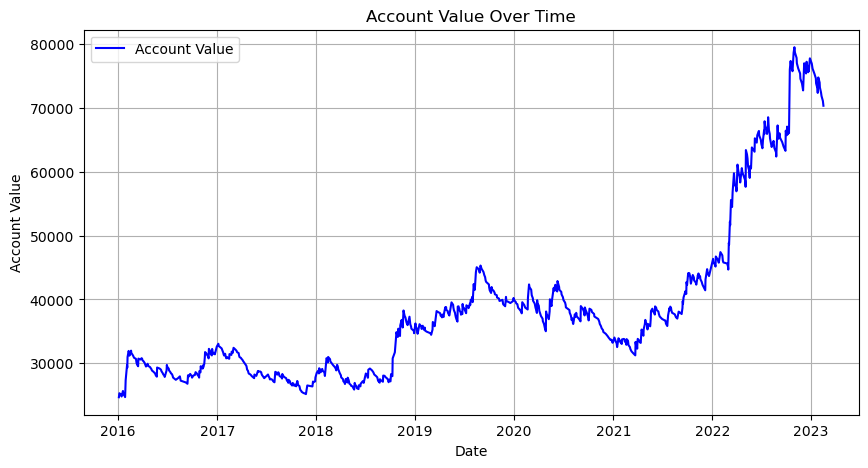

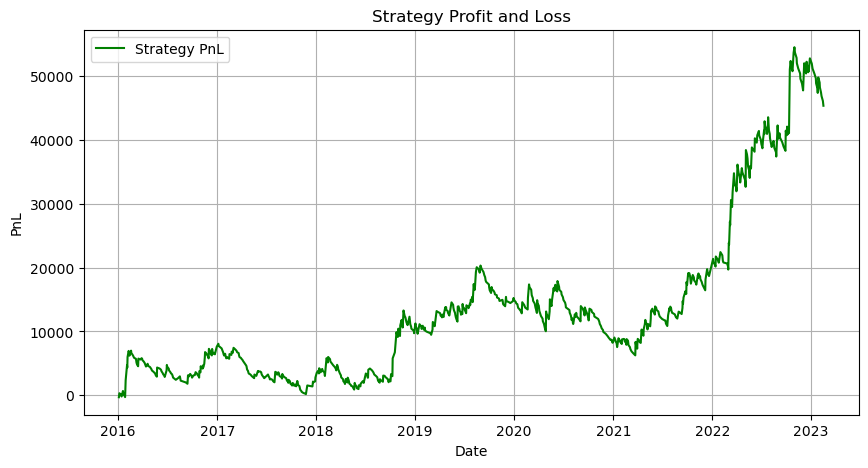

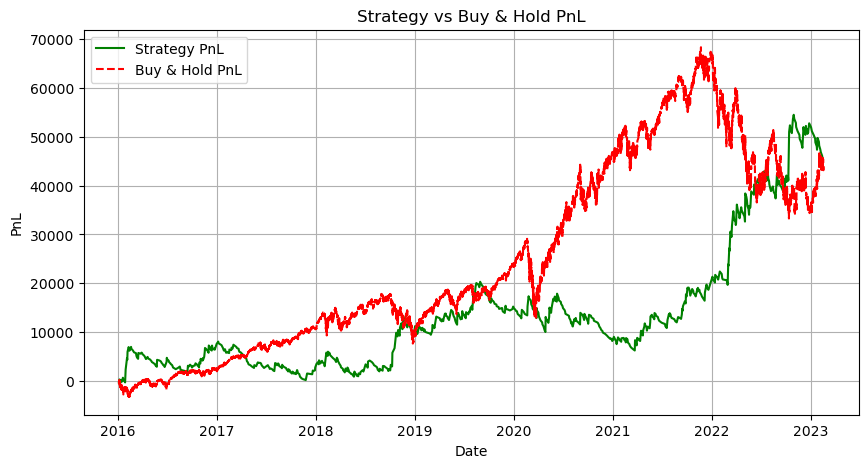

In [578]:
# Primo plot: Andamento dell’account
plt.figure(figsize=(10, 5))
plt.plot(traderone.dates, traderone.account[1:], label="Account Value", color='blue')
plt.xlabel("Date")
plt.ylabel("Account Value")
plt.title("Account Value Over Time")
plt.legend()
plt.grid()
plt.show()

# Secondo plot: Profit and Loss della strategia
plt.figure(figsize=(10, 5))
plt.plot(traderone.dates, traderone.pnl[1:], label="Strategy PnL", color='green')
plt.xlabel("Date")
plt.ylabel("PnL")
plt.title("Strategy Profit and Loss")
plt.legend()
plt.grid()
plt.show()

# Buy & Hold
initial_capital = traderone.account[0] if traderone.account else 0
shares = initial_capital / qqq_df['close'].iloc[0] if initial_capital else 0
qqq_df['trade'] = shares * (qqq_df['close'] - qqq_df['close'].iloc[0]) if initial_capital else 0

# Terzo plot: Confronto tra strategia e buy & hold
plt.figure(figsize=(10, 5))
plt.plot(traderone.dates, traderone.pnl[1:], label="Strategy PnL", color='green')
plt.plot(qqq_df['date'], qqq_df['trade'], label="Buy & Hold PnL", color='red', linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("PnL")
plt.title("Strategy vs Buy & Hold PnL")
plt.legend()
plt.grid()
plt.show()


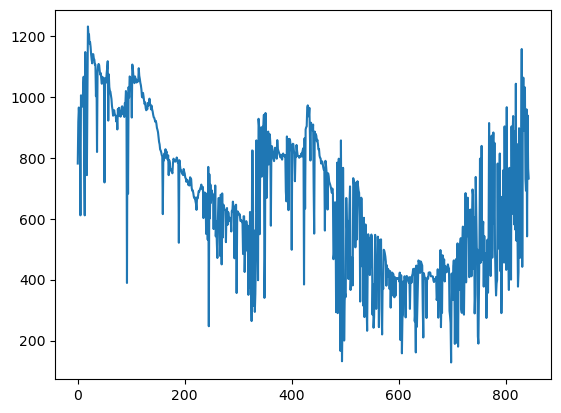

In [579]:
plt.plot(traderone.n_list)

In [580]:
print(np.mean(traderone.unit_trades))

0.12612559241706164


In [581]:
import numpy as np

initial_capital = traderone.account[0] if traderone.account else 0
trading_days = pd.to_datetime(sorted(qqq_df['day'].unique()))

if len(trading_days) == 0 or initial_capital == 0:
    raise ValueError('Unable to compute performance metrics: missing trading data or initial capital.')

strategy_index = pd.Index([trading_days[0]] + list(pd.to_datetime(traderone.dates)), name='date')
strategy_values = pd.Series(traderone.account, index=strategy_index)
strategy_equity = strategy_values.groupby(level=0).last().reindex(trading_days).ffill()

buy_hold_prices = qqq_df.groupby('day')['close'].last()
buy_hold_equity = initial_capital * buy_hold_prices / buy_hold_prices.iloc[0]
buy_hold_equity.index = pd.to_datetime(buy_hold_equity.index)
buy_hold_equity = buy_hold_equity.reindex(trading_days).ffill()

def compute_metrics(equity, periods_per_year=252):
    returns = equity.pct_change().dropna()
    if returns.empty:
        return pd.Series({
            'Sharpe Ratio': np.nan,
            'CAGR': np.nan,
            'Max Drawdown': np.nan,
            'Volatility': np.nan
        })
    sharpe = np.sqrt(periods_per_year) * returns.mean() / returns.std(ddof=1) if returns.std(ddof=1) != 0 else np.nan
    total_years = (equity.index[-1] - equity.index[0]).days / 365.25
    cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / total_years) - 1 if total_years > 0 else np.nan
    cumulative = equity / equity.iloc[0]
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()
    volatility = returns.std(ddof=1) * np.sqrt(periods_per_year)
    return pd.Series({
        'Sharpe Ratio': sharpe,
        'CAGR': cagr,
        'Max Drawdown': max_drawdown,
        'Volatility': volatility
    })

metrics_table = pd.DataFrame({
    'Strategy': compute_metrics(strategy_equity),
    'Buy & Hold': compute_metrics(buy_hold_equity)
})

formatted_table = pd.DataFrame(index=metrics_table.index, columns=metrics_table.columns, dtype=object)
row_formatters = {
    'Sharpe Ratio': lambda x: f'{x:.2f}',
    'CAGR': lambda x: f'{x:.2%}',
    'Max Drawdown': lambda x: f'{abs(x):.2%}',
    'Volatility': lambda x: f'{x:.2%}'
}
for metric, formatter in row_formatters.items():
    if metric in metrics_table.index:
        formatted_table.loc[metric] = metrics_table.loc[metric].map(
            lambda value: formatter(value) if pd.notnull(value) else 'N/A'
        )

display(formatted_table.T)


,Sharpe Ratio,CAGR,Max Drawdown,Volatility
Strategy,0.78,15.82%,31.03%,21.98%
Buy & Hold,0.72,15.25%,35.63%,23.41%
